# **PSL 2026 Data Analysis Capstone Project 📊**

---

### **Project Overview & Author Info**
* **Student Name:** Muhammad Rayyan Shehzad
* **Project Type:** Capstone Project (Data Visualization)
* **Contribution:** 99% Self Done

---

### **Dataset Details**
This project is based on the data of **Pakistan Super League (PSL) 2026** complete session

* **Source:** Kaggle
* **Dataset Identifier:** `alitaqishah/psl-2026-complete-season-dataset`

---

### **Main Concepts Used**

* **Missing Data Handling:** Cleaning null values to ensure accuracy.
* **Feature Extraction:** Deep Extracting key information from raw data.
* **New Columns Generation:** Creating new metrics (like `wickets` and `run_margin`).
* **Data Visualization:** Making charts and graphs to show PSL 2026 insights.

---
### **After thoughts & opinion**
Overall I gained experienced in `Pandas`, `matplotlib` and `seaborn` concepts. The intention was to practice Data Visualization but it helped me to skill up my pandas and logic building along the side. And I'm supper satisfied with the Project.

### **Loading Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

import warnings
warnings.filterwarnings("ignore")

### **Loading Dataset**

In [ ]:
from collections import defaultdict
import kagglehub


path = kagglehub.dataset_download("alitaqishah/psl-2026-complete-season-dataset")
print("Path to dataset files:", path)


files = os.listdir(path)
print("\nFolder mein yeh files hain:", files)

csv_files = [f for f in files if f.endswith('.csv')]

# for f in files:
#   if f.endswith(".csv"):
#      csv_files.append(f)

print("\nCSV files in the folder:", csv_files)


df = {}

for file in csv_files:
    file_path = os.path.join(path, file)

    df_name = file.replace('.csv', '')
    df[df_name] = pd.read_csv(file_path)
    print(f"Loaded: {file} as dataframes['{df_name}'] (Shape: {df[df_name].shape})")

100%|██████████| 6.77k/6.77k [00:00<00:00, 11.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alitaqishah/psl-2026-complete-season-dataset/versions/1

Folder mein yeh files hain: ['psl2026_player_stats.csv', 'psl2026_matches.csv', 'psl2026_auction.csv', 'psl2026_teams.csv']

CSV files in the folder: ['psl2026_player_stats.csv', 'psl2026_matches.csv', 'psl2026_auction.csv', 'psl2026_teams.csv']
Loaded: psl2026_player_stats.csv as dataframes['psl2026_player_stats'] (Shape: (37, 22))
Loaded: psl2026_matches.csv as dataframes['psl2026_matches'] (Shape: (44, 19))
Loaded: psl2026_auction.csv as dataframes['psl2026_auction'] (Shape: (136, 10))
Loaded: psl2026_teams.csv as dataframes['psl2026_teams'] (Shape: (9, 10))


### **Basic Information**

In [ ]:
df["psl2026_matches"].head()

,match_id,date,stage,venue,city,team1,team2,toss_winner,toss_decision,team1_score,team1_wickets,team1_overs,team2_score,team2_wickets,team2_overs,result,winner,win_margin,player_of_match
0,1,2026-03-26,League,Gaddafi Stadium,Lahore,Lahore Qalandars,Hyderabad Kingsmen,Lahore Qalandars,bat,162.0,8.0,20.0,163.0,4.0,17.3,Hyderabad Kingsmen won by 6 wkts,Hyderabad Kingsmen,6 wickets,Maaz Sadaqat
1,2,2026-03-27,League,National Bank Cricket Arena,Karachi,Karachi Kings,Quetta Gladiators,Karachi Kings,bat,178.0,6.0,20.0,162.0,9.0,20.0,Karachi Kings won by 16 runs,Karachi Kings,16 runs,David Warner
2,3,2026-03-28,League,Gaddafi Stadium,Lahore,Pindiz,Peshawar Zalmi,Peshawar Zalmi,field,148.0,9.0,20.0,149.0,3.0,16.4,Peshawar Zalmi won by 7 wkts,Peshawar Zalmi,7 wickets,Babar Azam
3,4,2026-03-29,League,National Bank Cricket Arena,Karachi,Islamabad United,Multan Sultans,Islamabad United,field,172.0,7.0,20.0,174.0,5.0,19.2,Multan Sultans won by 5 wkts,Multan Sultans,5 wickets,Shan Masood
4,5,2026-03-30,League,Gaddafi Stadium,Lahore,Quetta Gladiators,Hyderabad Kingsmen,Hyderabad Kingsmen,field,153.0,9.0,20.0,141.0,10.0,19.1,Quetta Gladiators won by 12 runs,Quetta Gladiators,12 runs,Abrar Ahmed


In [ ]:
df['psl2026_matches'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         44 non-null     int64  
 1   date             44 non-null     object 
 2   stage            44 non-null     object 
 3   venue            44 non-null     object 
 4   city             44 non-null     object 
 5   team1            44 non-null     object 
 6   team2            44 non-null     object 
 7   toss_winner      44 non-null     object 
 8   toss_decision    43 non-null     object 
 9   team1_score      43 non-null     float64
 10  team1_wickets    43 non-null     float64
 11  team1_overs      43 non-null     float64
 12  team2_score      43 non-null     float64
 13  team2_wickets    43 non-null     float64
 14  team2_overs      43 non-null     float64
 15  result           44 non-null     object 
 16  winner           44 non-null     object 
 17  win_margin       4

In [ ]:
df['psl2026_matches'].describe()

,match_id,team1_score,team1_wickets,team1_overs,team2_score,team2_wickets,team2_overs
count,44.000000,43.000000,43.000000,43.000000,43.000000,43.00000,43.000000
mean,22.500000,170.953488,6.744186,19.732558,156.976744,6.44186,18.306977
std,12.845233,25.450188,1.989173,0.763364,22.020000,2.71067,2.080224
min,1.000000,118.000000,3.000000,16.500000,80.000000,2.00000,12.300000
25%,11.750000,155.500000,5.000000,20.000000,144.500000,4.00000,17.250000
50%,22.500000,174.000000,6.000000,20.000000,161.000000,7.00000,19.300000
75%,33.250000,186.000000,8.000000,20.000000,172.500000,9.00000,20.000000
max,44.000000,246.000000,10.000000,20.000000,192.000000,10.00000,20.000000


In [ ]:
df["psl2026_matches"].shape

(44, 19)

In [ ]:
df['psl2026_matches'].columns

Index(['match_id', 'date', 'stage', 'venue', 'city', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'team1_score', 'team1_wickets',
       'team1_overs', 'team2_score', 'team2_wickets', 'team2_overs', 'result',
       'winner', 'win_margin', 'player_of_match'],
      dtype='object')

In [ ]:
df['psl2026_matches'].isnull().sum()

,0
match_id,0
date,0
stage,0
venue,0
city,0
team1,0
team2,0
toss_winner,0
toss_decision,1
team1_score,1


In [ ]:
df['psl2026_matches'].dropna(inplace=True)
df['psl2026_matches'].isna().sum()

,0
match_id,0
date,0
stage,0
venue,0
city,0
team1,0
team2,0
toss_winner,0
toss_decision,0
team1_score,0


In [ ]:
# df['psl2026_matches'].shape
print(f"Rows: {df['psl2026_matches'].shape[0]} , Columns: {df['psl2026_matches'].shape[1]}")

Rows: 43 , Columns: 19


### **Match Analysis Questions**

**Which team won the most matches?**

In [ ]:
wining_team = df['psl2026_matches']['winner'].value_counts()
wining_team

,count
winner,
Peshawar Zalmi,11
Hyderabad Kingsmen,7
Islamabad United,7
Lahore Qalandars,6
Karachi Kings,5
Multan Sultans,5
Quetta Gladiators,2


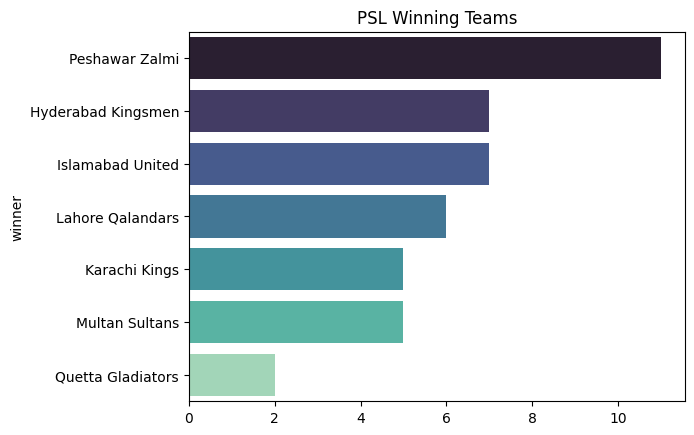

In [ ]:
sns.barplot(x= wining_team.values, y =wining_team.index, palette="mako")
plt.title("PSL Winning Teams")
plt.show()

**Toss Descision Trend**

In [ ]:
toss_decision = df['psl2026_matches']["toss_decision"].value_counts()
toss_decision

,count
toss_decision,
field,24
bat,19


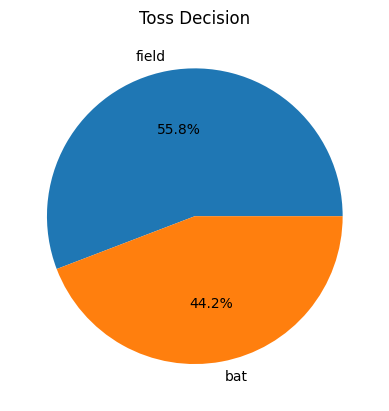

In [ ]:
plt.pie(x=toss_decision.values, labels=toss_decision.index, autopct='%1.1f%%')
plt.title("Toss Decision")
plt.show()

**Toss Winner vs Match Winner**

In [ ]:
df['psl2026_matches'][df['psl2026_matches']["toss_winner"] == df['psl2026_matches']["winner"]]["winner"].value_counts()

,count
winner,
Peshawar Zalmi,11
Islamabad United,7
Karachi Kings,5
Lahore Qalandars,3
Multan Sultans,3
Hyderabad Kingsmen,3
Quetta Gladiators,1


In [ ]:
count = df['psl2026_matches'][df['psl2026_matches']["toss_winner"] == df['psl2026_matches']["winner"]]["winner"].count()
pct = (count*100)/df['psl2026_matches'].shape[0]
pct.round(2)

np.float64(76.74)

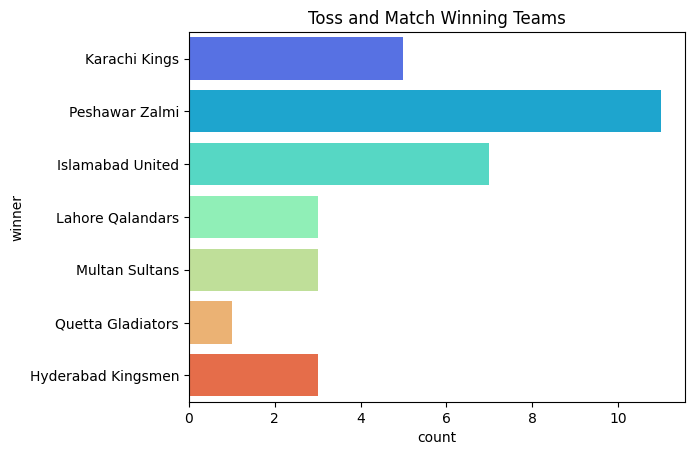

In [ ]:
count = df['psl2026_matches'][df['psl2026_matches']["toss_winner"] == df['psl2026_matches']["winner"]]["winner"]
sns.countplot(y=count, palette="rainbow")
plt.title("Toss and Match Winning Teams")
plt.show()

**How do team wins (Runs or Wickets)?**

In [ ]:
wickets = df['psl2026_matches'][df['psl2026_matches']['win_margin'].str.contains('wickets')]["win_margin"].value_counts().sum()

runs = df['psl2026_matches'][df['psl2026_matches']['win_margin'].str.contains('runs')]["win_margin"].value_counts().sum()

won_by = []
won_by.append(wickets)
won_by.append(runs)

won_by

[np.int64(21), np.int64(19)]

Text(0.5, 1.0, 'Won by Wickets and Runs')

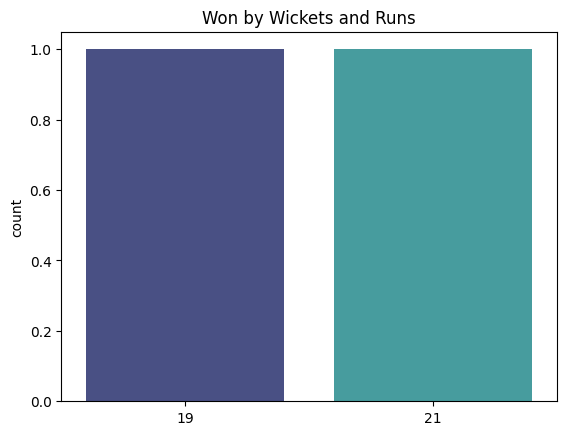

In [ ]:
sns.countplot(x=won_by, palette="mako")
plt.title("Won by Wickets and Runs")

### **Key Performance of Player**

**Most "Player of the Match" Awards**

In [ ]:
man_of_the_matches = df['psl2026_matches']["player_of_match"].value_counts()
man_of_the_matches

,count
player_of_match,
Babar Azam,5
Glenn Maxwell,4
Mark Chapman,4
Kusal Mendis,3
Maaz Sadaqat,2
Shan Masood,2
Fakhar Zaman,2
Aaron Hardie,2
Sahibzada Farhan,2


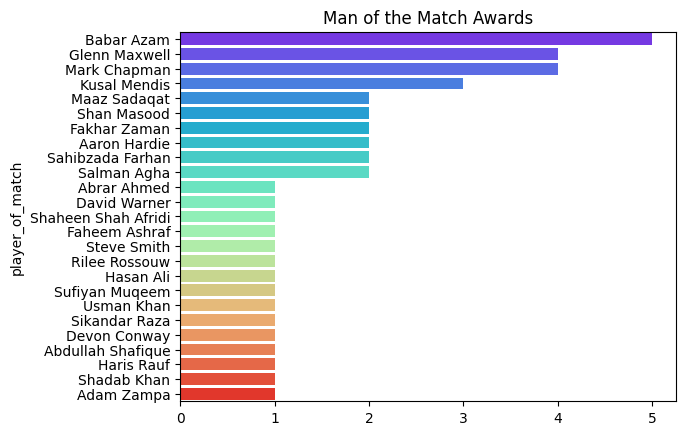

In [ ]:
sns.barplot(x=man_of_the_matches.values, y=man_of_the_matches.index, palette="rainbow")
plt.title("Man of the Match Awards")
plt.show()

**Top Scorer**

In [ ]:
df['psl2026_player_stats'].columns

Index(['player_name', 'team', 'nationality', 'role', 'matches', 'innings_bat',
       'runs', 'avg_bat', 'strike_rate', 'highest_score', 'not_outs',
       'fifties', 'hundreds', 'fours', 'sixes', 'innings_bowl', 'wickets',
       'avg_bowl', 'economy', 'best_bowling', 'four_wicket_hauls',
       'five_wicket_hauls'],
      dtype='object')

In [ ]:
df['psl2026_player_stats']["highest_score"]

,highest_score
0,116*
1,104
2,87
3,94
4,91
5,82
6,98
7,84
8,81
9,76


**Type Casting**

In [ ]:
df['psl2026_player_stats']["highest_score"].dtype

dtype('O')

In [ ]:
df['psl2026_player_stats']["highest_score"] = df['psl2026_player_stats']["highest_score"].str.replace("*", "")
df['psl2026_player_stats']["highest_score"]


,highest_score
0,116
1,104
2,87
3,94
4,91
5,82
6,98
7,84
8,81
9,76


In [ ]:
df['psl2026_player_stats']["highest_score"] = df['psl2026_player_stats']["highest_score"].astype(int)

In [ ]:
df['psl2026_player_stats']["highest_score"].dtype

dtype('int64')

In [ ]:
high_score = df['psl2026_player_stats'].groupby("player_name")
high_score

In [ ]:
high_score["highest_score"].sum().sort_values(ascending=False)
player_high_score = high_score["highest_score"].sum().sort_values(ascending=False).head(5)
player_high_score

,highest_score
player_name,
Babar Azam,116
Kusal Mendis,104
Sameer Minhas,98
Sahibzada Farhan,94
Steve Smith,91


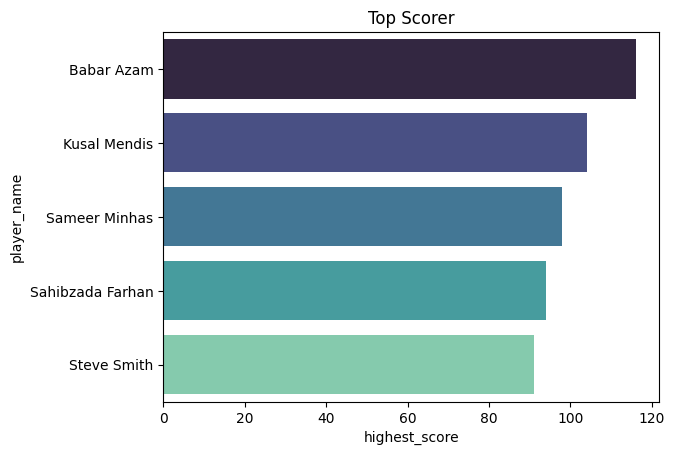

In [ ]:
sns.barplot(x=player_high_score, y= player_high_score.index, palette="mako")
plt.title("Top Scorer")
plt.show()

**Best Bowling Figures**

In [ ]:
df['psl2026_player_stats'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        37 non-null     object 
 1   team               37 non-null     object 
 2   nationality        37 non-null     object 
 3   role               37 non-null     object 
 4   matches            37 non-null     int64  
 5   innings_bat        37 non-null     int64  
 6   runs               37 non-null     int64  
 7   avg_bat            37 non-null     float64
 8   strike_rate        37 non-null     float64
 9   highest_score      37 non-null     int64  
 10  not_outs           37 non-null     int64  
 11  fifties            37 non-null     int64  
 12  hundreds           37 non-null     int64  
 13  fours              37 non-null     int64  
 14  sixes              37 non-null     int64  
 15  innings_bowl       37 non-null     int64  
 16  wickets            37 non-nu

In [ ]:
df['psl2026_player_stats'].head(20)

,player_name,team,nationality,role,matches,innings_bat,runs,avg_bat,strike_rate,highest_score,...,hundreds,fours,sixes,innings_bowl,wickets,avg_bowl,economy,best_bowling,four_wicket_hauls,five_wicket_hauls
0,Babar Azam,Peshawar Zalmi,Pakistan,Batsman,13,13,588,54.00,139.71,116,...,1,62,18,0,0,NaN,NaN,NaN,NaN,NaN
1,Kusal Mendis,Peshawar Zalmi,Sri Lanka,Wicketkeeper-Batsman,13,13,541,49.18,152.68,104,...,1,46,27,0,0,NaN,NaN,NaN,NaN,NaN
2,Fakhar Zaman,Lahore Qalandars,Pakistan,Batsman,12,12,401,38.27,143.21,87,...,0,42,19,0,0,NaN,NaN,NaN,NaN,NaN
3,Sahibzada Farhan,Multan Sultans,Pakistan,Batsman,12,12,380,34.54,155.31,94,...,0,28,28,0,0,NaN,NaN,NaN,NaN,NaN
4,Steve Smith,Sialkot Stallionz,Australia,Batsman,11,11,380,38.00,141.26,91,...,0,38,14,0,0,NaN,NaN,NaN,NaN,NaN
5,Shan Masood,Multan Sultans,Pakistan,Batsman,12,12,367,33.36,138.49,82,...,0,32,16,1,0,NaN,NaN,NaN,NaN,NaN
6,Sameer Minhas,Islamabad United,Pakistan,Batsman,12,12,354,35.40,161.64,98,...,0,30,22,0,0,NaN,NaN,NaN,NaN,NaN
7,Glenn Maxwell,Hyderabad Kingsmen,Australia,All-rounder,12,12,341,37.89,188.40,84,...,0,22,28,9,8,32.25,8.82,4/24,1.0,0.0
8,Mark Chapman,Islamabad United,New Zealand,Batsman,13,13,336,33.60,147.36,81,...,0,31,18,0,0,NaN,NaN,NaN,NaN,NaN
9,Usman Khan,Hyderabad Kingsmen,Pakistan,Batsman,12,12,312,31.20,162.50,76,...,0,26,20,0,0,NaN,NaN,NaN,NaN,NaN


**Handling Missing Data**

In [ ]:
import random

In [ ]:
bowling_value = df['psl2026_player_stats']['best_bowling'].unique()
bowling_value[0] = "3/20" # wickets/balls
bowling_value.astype(str)
bowling_value.ndim

df['psl2026_player_stats']['best_bowling'] = bowling_value = df['psl2026_player_stats']['best_bowling'].fillna(random.choice(bowling_value))


In [ ]:
df['psl2026_player_stats']['best_bowling'].isna().sum()

np.int64(0)

**Wickets Extraction**

In [ ]:
def extract(txt):
  data = txt[0]
  # data = txt.split('/')[0]
  data = int(data)
  return data


In [ ]:
df['psl2026_player_stats']["highest_wickets"] = df['psl2026_player_stats']['best_bowling'].apply(extract)

In [ ]:
df['psl2026_player_stats'].head()

,player_name,team,nationality,role,matches,innings_bat,runs,avg_bat,strike_rate,highest_score,...,fours,sixes,innings_bowl,wickets,avg_bowl,economy,best_bowling,four_wicket_hauls,five_wicket_hauls,highest_wickets
0,Babar Azam,Peshawar Zalmi,Pakistan,Batsman,13,13,588,54.00,139.71,116,...,62,18,0,3,NaN,NaN,3/20,NaN,NaN,3
1,Kusal Mendis,Peshawar Zalmi,Sri Lanka,Wicketkeeper-Batsman,13,13,541,49.18,152.68,104,...,46,27,0,3,NaN,NaN,3/20,NaN,NaN,3
2,Fakhar Zaman,Lahore Qalandars,Pakistan,Batsman,12,12,401,38.27,143.21,87,...,42,19,0,3,NaN,NaN,3/20,NaN,NaN,3
3,Sahibzada Farhan,Multan Sultans,Pakistan,Batsman,12,12,380,34.54,155.31,94,...,28,28,0,3,NaN,NaN,3/20,NaN,NaN,3
4,Steve Smith,Sialkot Stallionz,Australia,Batsman,11,11,380,38.00,141.26,91,...,38,14,0,3,NaN,NaN,3/20,NaN,NaN,3


In [ ]:
top_bowlers = df['psl2026_player_stats']["highest_wickets"].groupby(df['psl2026_player_stats']["player_name"]).sum().sort_values(ascending=False)
top_bowlers

,highest_wickets
player_name,
Aaron Hardie,4
Sufiyan Muqeem,4
Shaheen Shah Afridi,4
Iftikhar Ahmed,4
Glenn Maxwell,4
Sameer Minhas,3
Babar Azam,3
Adam Zampa,3
Abrar Ahmed,3


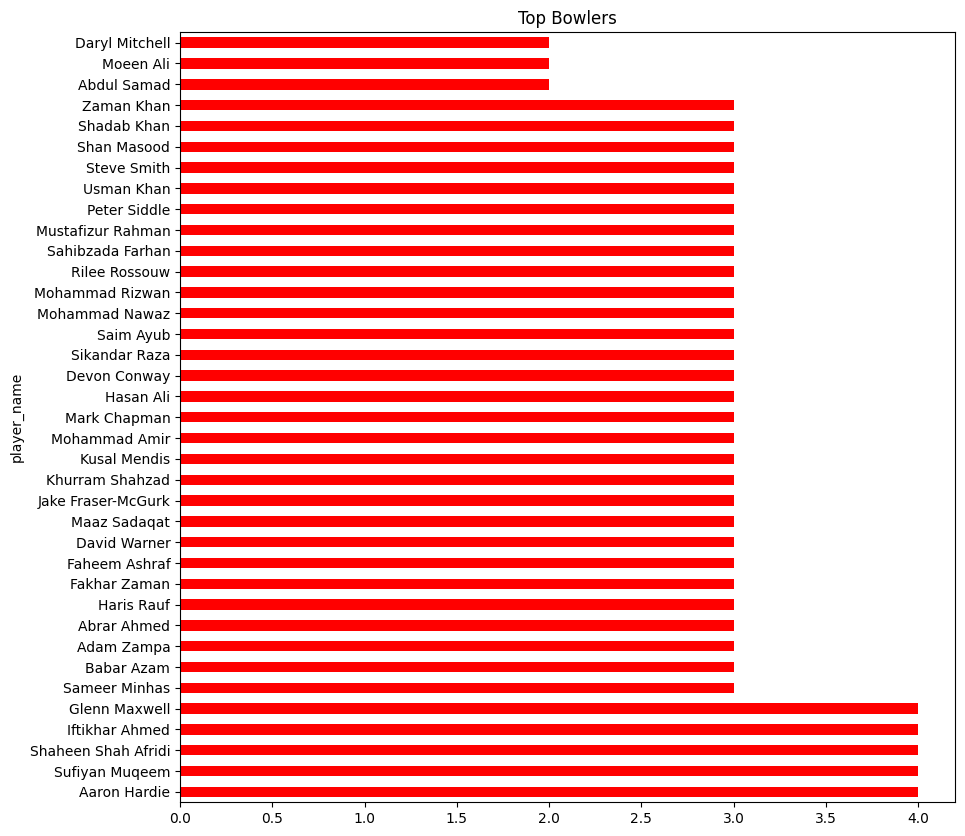

In [ ]:
plt.figure(figsize=(10,10))
top_bowlers.plot(kind = "barh", color="red")
plt.title("Top Bowlers")
plt.show()

### **Venue Analysis**

**Most matches played by venue**

In [ ]:
df['psl2026_teams'].head()

,team_name,short_code,city,home_venue,owner,franchise_type,psl_titles,seasons_in_psl,league_position_2026,playoff_result_2026
0,Peshawar Zalmi,PSZ,Peshawar,Gaddafi Stadium (neutral),Javed Afridi,Original (renewed),2,11,1st,Champions
1,Islamabad United,ISU,Islamabad,National Bank Cricket Arena (neutral),ARY Group,Original (renewed),3,11,2nd,Eliminated (Eliminator 2)
2,Multan Sultans,MS,Multan,National Bank Cricket Arena (neutral),Walee Technologies,Rebranded from Rawalpindiz,0,1,3rd,Eliminated (Eliminator 1)
3,Hyderabad Kingsmen,HHK,Hyderabad,Gaddafi Stadium (neutral),FKS Group,New franchise,0,1,4th,Runners-up
4,Lahore Qalandars,LHQ,Lahore,Gaddafi Stadium,Fawad Rana,Original (renewed),3,11,5th,Did not qualify


In [ ]:
venue_count = df['psl2026_teams']['home_venue'].value_counts()
venue_count

,count
home_venue,
Gaddafi Stadium (neutral),3
National Bank Cricket Arena (neutral),2
Gaddafi Stadium,1
National Bank Cricket Arena,1
Rawalpindi Cricket Stadium,1
Iqbal Stadium (neutral),1


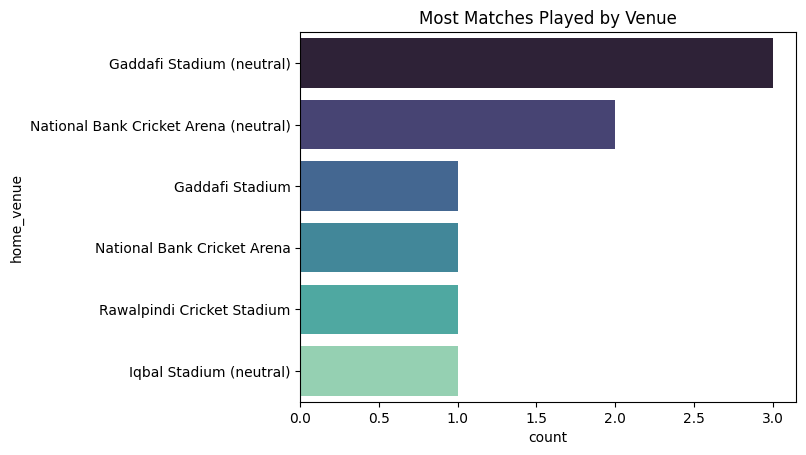

In [ ]:
sns.barplot(x=venue_count, y=venue_count.index, palette="mako")
plt.title("Most Matches Played by Venue")
plt.show()

### **Extra Questions & Insights**

**Who won the highest margin by runs?**

In [ ]:
 df['psl2026_matches'].head()

,match_id,date,stage,venue,city,team1,team2,toss_winner,toss_decision,team1_score,team1_wickets,team1_overs,team2_score,team2_wickets,team2_overs,result,winner,win_margin,player_of_match
0,1,2026-03-26,League,Gaddafi Stadium,Lahore,Lahore Qalandars,Hyderabad Kingsmen,Lahore Qalandars,bat,162.0,8.0,20.0,163.0,4.0,17.3,Hyderabad Kingsmen won by 6 wkts,Hyderabad Kingsmen,6 wickets,Maaz Sadaqat
1,2,2026-03-27,League,National Bank Cricket Arena,Karachi,Karachi Kings,Quetta Gladiators,Karachi Kings,bat,178.0,6.0,20.0,162.0,9.0,20.0,Karachi Kings won by 16 runs,Karachi Kings,16 runs,David Warner
2,3,2026-03-28,League,Gaddafi Stadium,Lahore,Pindiz,Peshawar Zalmi,Peshawar Zalmi,field,148.0,9.0,20.0,149.0,3.0,16.4,Peshawar Zalmi won by 7 wkts,Peshawar Zalmi,7 wickets,Babar Azam
3,4,2026-03-29,League,National Bank Cricket Arena,Karachi,Islamabad United,Multan Sultans,Islamabad United,field,172.0,7.0,20.0,174.0,5.0,19.2,Multan Sultans won by 5 wkts,Multan Sultans,5 wickets,Shan Masood
4,5,2026-03-30,League,Gaddafi Stadium,Lahore,Quetta Gladiators,Hyderabad Kingsmen,Hyderabad Kingsmen,field,153.0,9.0,20.0,141.0,10.0,19.1,Quetta Gladiators won by 12 runs,Quetta Gladiators,12 runs,Abrar Ahmed


**Run Margin Extraction**

In [ ]:
df_new = df['psl2026_matches'][df['psl2026_matches']['win_margin'].str.contains('runs')]
df_new

,match_id,date,stage,venue,city,team1,team2,toss_winner,toss_decision,team1_score,team1_wickets,team1_overs,team2_score,team2_wickets,team2_overs,result,winner,win_margin,player_of_match
1,2,2026-03-27,League,National Bank Cricket Arena,Karachi,Karachi Kings,Quetta Gladiators,Karachi Kings,bat,178.0,6.0,20.0,162.0,9.0,20.0,Karachi Kings won by 16 runs,Karachi Kings,16 runs,David Warner
4,5,2026-03-30,League,Gaddafi Stadium,Lahore,Quetta Gladiators,Hyderabad Kingsmen,Hyderabad Kingsmen,field,153.0,9.0,20.0,141.0,10.0,19.1,Quetta Gladiators won by 12 runs,Quetta Gladiators,12 runs,Abrar Ahmed
10,11,2026-04-05,League,Gaddafi Stadium,Lahore,Lahore Qalandars,Multan Sultans,Lahore Qalandars,bat,183.0,5.0,20.0,172.0,8.0,20.0,Lahore Qalandars won by 11 runs,Lahore Qalandars,11 runs,Shaheen Shah Afridi
16,17,2026-04-11,League,Gaddafi Stadium,Lahore,Peshawar Zalmi,Karachi Kings,Peshawar Zalmi,bat,198.0,4.0,20.0,162.0,9.0,20.0,Peshawar Zalmi won by 36 runs,Peshawar Zalmi,36 runs,Babar Azam
17,18,2026-04-12,League,National Bank Cricket Arena,Karachi,Quetta Gladiators,Pindiz,Quetta Gladiators,bat,171.0,6.0,20.0,148.0,10.0,19.2,Quetta Gladiators won by 23 runs,Quetta Gladiators,23 runs,Rilee Rossouw
18,19,2026-04-13,League,Gaddafi Stadium,Lahore,Peshawar Zalmi,Lahore Qalandars,Peshawar Zalmi,bat,187.0,5.0,20.0,174.0,8.0,20.0,Peshawar Zalmi won by 13 runs,Peshawar Zalmi,13 runs,Sufiyan Muqeem
20,21,2026-04-15,League,Gaddafi Stadium,Lahore,Islamabad United,Hyderabad Kingsmen,Islamabad United,bat,184.0,6.0,20.0,80.0,10.0,13.2,Islamabad United won by 104 runs,Islamabad United,104 runs,Mark Chapman
21,22,2026-04-16,League,National Bank Cricket Arena,Karachi,Peshawar Zalmi,Multan Sultans,Peshawar Zalmi,bat,192.0,5.0,20.0,176.0,8.0,20.0,Peshawar Zalmi won by 16 runs,Peshawar Zalmi,16 runs,Babar Azam
25,26,2026-04-20,League,National Bank Cricket Arena,Karachi,Lahore Qalandars,Quetta Gladiators,Lahore Qalandars,bat,174.0,6.0,20.0,158.0,9.0,20.0,Lahore Qalandars won by 16 runs,Lahore Qalandars,16 runs,Sikandar Raza
26,27,2026-04-21,League,Gaddafi Stadium,Lahore,Lahore Qalandars,Pindiz,Lahore Qalandars,bat,206.0,4.0,20.0,143.0,10.0,17.3,Lahore Qalandars won by 63 runs,Lahore Qalandars,63 runs,Abdullah Shafique


In [ ]:
run_margin = df['psl2026_matches']['win_margin'][df['psl2026_matches']['win_margin'].str.contains('runs')]

In [ ]:
def extract(txt):
  data = txt.split(' ')[0]
  data = int(data)
  return data

In [ ]:
store_margin = run_margin.apply(extract)
df_new["run_margin"] = store_margin

In [ ]:
df_new.head()

,match_id,date,stage,venue,city,team1,team2,toss_winner,toss_decision,team1_score,team1_wickets,team1_overs,team2_score,team2_wickets,team2_overs,result,winner,win_margin,player_of_match,run_margin
1,2,2026-03-27,League,National Bank Cricket Arena,Karachi,Karachi Kings,Quetta Gladiators,Karachi Kings,bat,178.0,6.0,20.0,162.0,9.0,20.0,Karachi Kings won by 16 runs,Karachi Kings,16 runs,David Warner,16
4,5,2026-03-30,League,Gaddafi Stadium,Lahore,Quetta Gladiators,Hyderabad Kingsmen,Hyderabad Kingsmen,field,153.0,9.0,20.0,141.0,10.0,19.1,Quetta Gladiators won by 12 runs,Quetta Gladiators,12 runs,Abrar Ahmed,12
10,11,2026-04-05,League,Gaddafi Stadium,Lahore,Lahore Qalandars,Multan Sultans,Lahore Qalandars,bat,183.0,5.0,20.0,172.0,8.0,20.0,Lahore Qalandars won by 11 runs,Lahore Qalandars,11 runs,Shaheen Shah Afridi,11
16,17,2026-04-11,League,Gaddafi Stadium,Lahore,Peshawar Zalmi,Karachi Kings,Peshawar Zalmi,bat,198.0,4.0,20.0,162.0,9.0,20.0,Peshawar Zalmi won by 36 runs,Peshawar Zalmi,36 runs,Babar Azam,36
17,18,2026-04-12,League,National Bank Cricket Arena,Karachi,Quetta Gladiators,Pindiz,Quetta Gladiators,bat,171.0,6.0,20.0,148.0,10.0,19.2,Quetta Gladiators won by 23 runs,Quetta Gladiators,23 runs,Rilee Rossouw,23


In [ ]:
df_new.sort_values(by="run_margin" ,ascending=False).head(1)[["winner","win_margin"]]

,winner,win_margin
20,Islamabad United,104 runs


**Which player had the highest individual score?**

In [ ]:
df['psl2026_player_stats'].head()

,player_name,team,nationality,role,matches,innings_bat,runs,avg_bat,strike_rate,highest_score,...,fours,sixes,innings_bowl,wickets,avg_bowl,economy,best_bowling,four_wicket_hauls,five_wicket_hauls,highest_wickets
0,Babar Azam,Peshawar Zalmi,Pakistan,Batsman,13,13,588,54.00,139.71,116,...,62,18,0,3,NaN,NaN,3/20,NaN,NaN,3
1,Kusal Mendis,Peshawar Zalmi,Sri Lanka,Wicketkeeper-Batsman,13,13,541,49.18,152.68,104,...,46,27,0,3,NaN,NaN,3/20,NaN,NaN,3
2,Fakhar Zaman,Lahore Qalandars,Pakistan,Batsman,12,12,401,38.27,143.21,87,...,42,19,0,3,NaN,NaN,3/20,NaN,NaN,3
3,Sahibzada Farhan,Multan Sultans,Pakistan,Batsman,12,12,380,34.54,155.31,94,...,28,28,0,3,NaN,NaN,3/20,NaN,NaN,3
4,Steve Smith,Sialkot Stallionz,Australia,Batsman,11,11,380,38.00,141.26,91,...,38,14,0,3,NaN,NaN,3/20,NaN,NaN,3


In [ ]:
df['psl2026_player_stats'][df['psl2026_player_stats']['highest_score'] == df['psl2026_player_stats']['highest_score'].max()][["player_name", "highest_score"]]


,player_name,highest_score
0,Babar Azam,116


**Which Bowler had the best bowling figures?**

In [ ]:
df['psl2026_player_stats'].head()

,player_name,team,nationality,role,matches,innings_bat,runs,avg_bat,strike_rate,highest_score,...,fours,sixes,innings_bowl,wickets,avg_bowl,economy,best_bowling,four_wicket_hauls,five_wicket_hauls,highest_wickets
0,Babar Azam,Peshawar Zalmi,Pakistan,Batsman,13,13,588,54.00,139.71,116,...,62,18,0,3,NaN,NaN,3/20,NaN,NaN,3
1,Kusal Mendis,Peshawar Zalmi,Sri Lanka,Wicketkeeper-Batsman,13,13,541,49.18,152.68,104,...,46,27,0,3,NaN,NaN,3/20,NaN,NaN,3
2,Fakhar Zaman,Lahore Qalandars,Pakistan,Batsman,12,12,401,38.27,143.21,87,...,42,19,0,3,NaN,NaN,3/20,NaN,NaN,3
3,Sahibzada Farhan,Multan Sultans,Pakistan,Batsman,12,12,380,34.54,155.31,94,...,28,28,0,3,NaN,NaN,3/20,NaN,NaN,3
4,Steve Smith,Sialkot Stallionz,Australia,Batsman,11,11,380,38.00,141.26,91,...,38,14,0,3,NaN,NaN,3/20,NaN,NaN,3


In [ ]:
df['psl2026_player_stats'][df['psl2026_player_stats']['highest_wickets'] == df['psl2026_player_stats']['highest_wickets'].max()][["player_name","best_bowling"]]

,player_name,best_bowling
7,Glenn Maxwell,4/24
12,Aaron Hardie,4/24
13,Sufiyan Muqeem,4/18
14,Shaheen Shah Afridi,4/18
30,Iftikhar Ahmed,4/21


---
End